<p><img alt="UdeA logo" height="250px" src="https://upload.wikimedia.org/wikipedia/commons/f/fb/Escudo-UdeA.svg" align="left" hspace="10px" ></p>

<h1><b>Practice 3 - Photoelectric effect - Experimental Physics IV<b></h1>
<div align="left+">
<h2><b>Institute of Physics<b></h2>

<font size=3>
Estiven Castrillon - estiven.castrillon2@udea.edu.co<br>
Ana Sofía Mora - ana.mora@udea.edu.co<br>
Sebastián Duque - sebastian.duque6@udea.edu.co<br>
Alejandro Arboleda - dalejandro.arboleda1@udea.edu.co<br>
</font>
</div>

# Introduction

The photoelectric effect represents one of the pillars of modern physics, marking the transition from the classical wave description of light to quantum theory. In 1905, Albert Einstein proposed that light is not distributed continuously in space, but rather consists of a finite number of energy packets or "quanta" (photons) localized at points in space, which move without dividing and can only be absorbed or produced as complete units. [1]

Despite the boldness of this hypothesis, it was Robert Millikan in 1916 who, through precise experimental design, successfully validated the linear relationship predicted by Einstein. [2] In this practice, we replicate this historic milestone of modern physics using a Cesium cell and light-emitting diodes (LEDs) of different colors (Blue, Green, Yellow, and Red) to determine Planck's constant ($h$) and the work function ($\phi$) of the material.

## Theoretical basis

The theoretical basis of the experiment lies in the energy transfer from an individual photon to an electron within the metal.

## Einstein's equation

When a photon of frequency $f$ strikes the surface of a metal, its energy $E = hf$ is absorbed by an electron. This energy is used in two ways:

1. To overcome the work function $\phi$, which is the minimum energy required to remove an electron from the material.
2. The remainder is converted into the maximum kinetic energy $K_{\text{max}}$ of the emitted electron.

Mathematically, it is expressed as:

$$
hf = K_{\text{max}} + \phi
$$

## Stopping potential $V_0$

To measure $K_{\text{max}}$, a reverse (retarding) electric potential is applied that opposes the motion of electrons. The specific voltage that manages to stop even the most energetic electrons is called the stopping potential, which we will denote as $V_0$.

At this point, the electric potential energy equals the kinetic energy:

$$
eV_0 = K_{\text{max}}
$$

Substituting into Einstein's equation, we obtain the linear model used in the analysis:

$$
V_0 = \left( \frac{h}{e} \right) f - \frac{\phi}{e}
$$

## Physical parameters

- $h$: Planck's constant ($6.626\times10^{-34}\ \text{J} \cdot \text{s}$) (accepted value according to [3]).
- $e$: Electron charge ($1.602\times10^{-19}\ \text{C}$).
- $f$: Frequency of incident light.
- $\phi$: Work function of the material (Cesium in this case).

# Development

The experiment is divided into two main phases: characterization of the light source and measurement of the electrical response of the material.

## Spectral characterization of LEDs

Instead of using a mercury lamp with filters, commercial LEDs of various colors were employed. Since LEDs do not emit at a single pure frequency, the following was done:

1. The emission spectrum was measured for each LED (Blue, Green, Yellow, Red).
2. The dominant wavelength $\lambda$ was identified using the peak of maximum intensity in the spectral data.
3. The associated frequency was calculated using the speed of light $c$:

$$
f = \frac{c}{\lambda}
$$

In [11]:
# Import data and libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import curve_fit

# Physical constants
c = 299792458          # speed of light [m/s]
e = 1.602176634e-19    # electron charge [C]

# Plot style
sns.set_theme(context='paper', style='whitegrid', font='serif', font_scale=1.2)
plt.rcParams.update({
    "axes.linewidth": 1.2,
    "axes.labelweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "grid.linestyle": "--",
    "legend.frameon": True,
    "legend.edgecolor": "black",
    "legend.fancybox": False,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "ytick.minor.visible": True,
    "xtick.minor.visible": True,
    "figure.dpi": 150,
})

def read_csv(file_path):
    """
    Reads a CSV file and:
    - Selects data starting from row 54
    - Removes the last row
    - Separates the single column by ';' into wavelength and intensity
    """

    df = pd.read_csv(
        file_path,
        header=None
    )

    df = df.iloc[53:-1]  # data filter
    df = df[0].str.split(';', expand=True)  # column separation
    df[0] = pd.to_numeric(df[0], errors='coerce')  # conversion to numbers
    df[1] = pd.to_numeric(df[1], errors='coerce')
    df.columns = ['wavelength_nm', 'intensity']  # column names
    df = df.dropna()
    df = df.reset_index(drop=True)

    return df

blue_led = read_csv('data/led_azul.csv')
yellow_led = read_csv('data/led_amarillo.csv')
red_led = read_csv('data/led_rojo.csv')
green_led = read_csv('data/led_verde.csv')

In [12]:
print("Blue LED:")
display(blue_led.head(2))

print("\nGreen LED:")
display(green_led.head(2))

print("\nYellow LED:")
display(yellow_led.head(2))

print("\nRed LED:")
display(red_led.head(2))

Blue LED:


,wavelength_nm,intensity
0,321.706024,-0.000828
1,321.813721,-0.000468



Green LED:


,wavelength_nm,intensity
0,321.706024,0.000346
1,321.813721,-0.001073



Yellow LED:


,wavelength_nm,intensity
0,321.706024,0.000741
1,321.813721,0.000201



Red LED:


,wavelength_nm,intensity
0,321.706024,-0.000128
1,321.813721,-0.000468


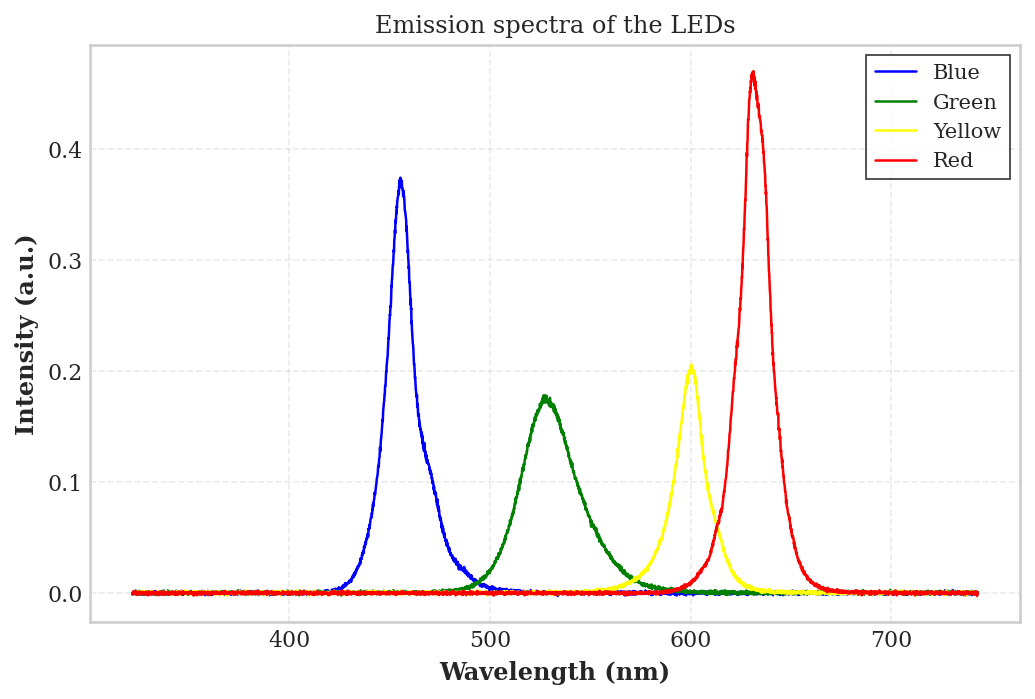

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(blue_led['wavelength_nm'], blue_led['intensity'], label='Blue', color='blue')
plt.plot(green_led['wavelength_nm'], green_led['intensity'], label='Green', color='green')
plt.plot(yellow_led['wavelength_nm'], yellow_led['intensity'], label='Yellow', color='yellow')
plt.plot(red_led['wavelength_nm'], red_led['intensity'], label='Red', color='red')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity (a.u.)')
plt.title('Emission spectra of the LEDs')
plt.legend()
plt.grid(True)

plt.show()

## Data analysis

Finally, the data were processed using a linear regression of $V_0$ as a function of $f$. According to the theoretical model, the slope of this line corresponds to the ratio $h/e$, allowing Planck's constant to be solved for, while the intercept with the vertical axis allows the work function of Cesium to be calculated.

In [14]:
def dominant_wavelength(df):
    max_index = df['intensity'].idxmax()
    return df.loc[max_index, 'wavelength_nm']

lambda_blue_nm = dominant_wavelength(blue_led)
lambda_green_nm = dominant_wavelength(green_led)
lambda_yellow_nm = dominant_wavelength(yellow_led)
lambda_red_nm = dominant_wavelength(red_led)

print("Dominant wavelengths (nm):")
print(f"Blue: {lambda_blue_nm:.2f}")
print(f"Green: {lambda_green_nm:.2f}")
print(f"Yellow: {lambda_yellow_nm:.2f}")
print(f"Red: {lambda_red_nm:.2f}")

Dominant wavelengths (nm):
Blue: 455.32
Green: 526.69
Yellow: 600.24
Red: 631.24


In [15]:
def frequency_from_lambda(lambda_nm):
    """
    Converts wavelength in nanometers to frequency in Hz using the formula:
    f = c / λ
    """
    lambda_m = lambda_nm * 1e-9
    return c / lambda_m


frequencies = np.array([
    frequency_from_lambda(lambda_blue_nm),
    frequency_from_lambda(lambda_green_nm),
    frequency_from_lambda(lambda_yellow_nm),
    frequency_from_lambda(lambda_red_nm)
])

colors = ["Blue", "Green", "Yellow", "Red"]
print("Frequencies associated with each color:")
for color, f in zip(colors, frequencies):
    print(f"{color}: {f:.2e} Hz")

Frequencies associated with each color:
Blue: 6.58e+14 Hz
Green: 5.69e+14 Hz
Yellow: 4.99e+14 Hz
Red: 4.75e+14 Hz


# Results

In [16]:
V0 = np.array([
    0.86,  # Blue
    0.64,  # Green
    0.55,  # Yellow
    0.37   # Red
])

def photoelectric_model(nu, h, phi):
    return (h / e) * nu - (phi / e)

mask = ~np.isnan(V0)
nu_fit = frequencies[mask]
V0_fit = V0[mask]

# Nonlinear fitting
parameters, covariance = curve_fit(
    photoelectric_model,
    nu_fit,
    V0_fit,
)

h_estimated, phi_estimated = parameters

print("Fitting results:")
print(f"h estimated = {h_estimated:.2e} J·s")
print(f"φ estimated = {phi_estimated / e:.2f} eV")

Fitting results:
h estimated = 3.84e-34 J·s
φ estimated = 0.72 eV


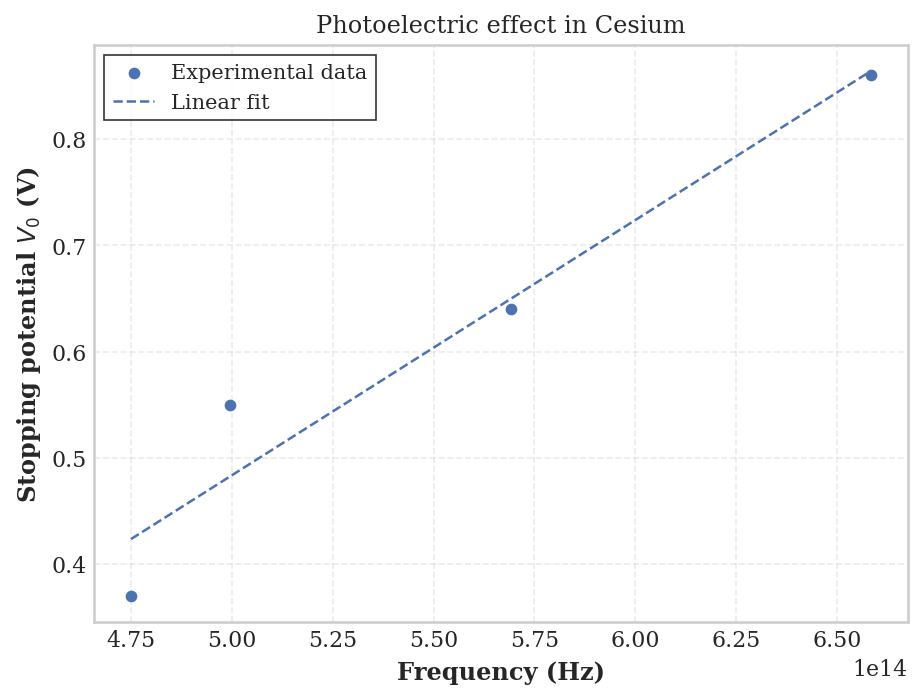

In [17]:
nu_continuous = np.linspace(nu_fit.min(), nu_fit.max(), 500)
V0_fit_line = photoelectric_model(nu_continuous, h_estimated, phi_estimated)

plt.figure(figsize=(7, 5))
plt.scatter(nu_fit, V0_fit, label='Experimental data')
plt.plot(nu_continuous, V0_fit_line, label='Linear fit', linestyle='--')

plt.xlabel('Frequency (Hz)')
plt.ylabel('Stopping potential $V_0$ (V)')
plt.title('Photoelectric effect in Cesium')
plt.legend()
plt.grid(True)

plt.show()

In [18]:
# Calculate the error of Planck's constant compared with the normally accepted value

h_accepted = 6.62607015e-34
error_h = np.abs((h_estimated - h_accepted) / h_accepted) * 100
print(f"Error in h: {error_h:.2f}%")

Error in h: 41.98%


After processing the data obtained from the four LEDs (Blue, Green, Yellow, and Red) and applying a linear fit based on Einstein's equation, the following experimental values were obtained.

## Calculated values

- **Estimated Planck constant**:  
  $h = 3.844 \times 10^{-34}\ \text{Js}$  

- **Work function of Cesium**:  
  $\phi = 0.716\ \text{eV}$  

## Error analysis

To evaluate the accuracy of the measurement, the obtained value was compared with the internationally accepted Planck constant:

$$
h_{\text{accepted}} = 6.626 \times 10^{-34}\ \text{Js}
$$

| Parameter | Experimental Value | Accepted Value | Relative Error |
|-----------|--------------------|----------------|----------------|
| Planck constant ($h$) | $3.844\times10^{-34}$ J·s | $6.626\times10^{-34}$ J·s | 41.98% |

## Discussion of uncertainties

The error of **41.98%** is considerably high compared to similar experiments in undergraduate laboratories, where deviations of **10% to 18%** are typically reported. This discrepancy can be attributed to several factors identified in the technical literature:

1. **Calibration Drift:**  
   Equipment heating and light source instability can generate drift that alters current and voltage readings.

2. **Ambient Light and Parasitic Currents:**  
   Millikan [2] noted that diffuse light of short wavelengths (*falsches Licht*) can modify the stopping potential curves, shifting the intercepts toward incorrect values.

3. **LED Spectrum:**  
   Unlike a mercury lamp, LEDs emit over a range of wavelengths (bandwidth) rather than at a single frequency, which introduces uncertainty when defining the dominant frequency.

4. **Work Function:**  
   The value obtained for Cesium ($0.716\ \text{eV}$) is lower than the typical literature value (approx. $2.1\ \text{eV}$). This may be due to oxidation of the metal surface or the contact potential between the tube's electrodes.

# Conclusions

- **Validation of the Linear Model:**  
  Despite the numerical error in Planck's constant, the experimental data confirm the linear relationship between the frequency of incident light and the stopping potential ($V_0 \propto f$), as Einstein predicted in 1905 and Millikan verified in 1916.

- **Nature of Quanta:**  
  The experiment demonstrates that the energy of emitted electrons depends exclusively on the frequency (color) of light and not on its intensity, which is inconsistent with classical wave theory and validates the hypothesis of photons or energy quanta.

- **Effectiveness of the study:**  
  Although the error of 41.98% suggests that the setup requires improvements in ambient light isolation and electrical stability, the practice is effective for demonstrating the concept of energy quantization at the atomic level using low-cost devices such as LEDs.

# References
- [1] “Einstein, A. (1905) Concerning an Heuristic Point of View toward the Emission and Transformation of Light. Annalen der Physik, 17, 132-148. - References - Scientific Research Publishing,” Scirp.org, 2026. http://dx.doi.org/10.1002/andp.19053220607 (accessed Jan. 24, 2026).

- [2] R. A. Millikan, “A Direct Photoelectric Determination of Planck’s ‘h,’” Physical Review, vol. 7, no. 3, pp. 355-388, Mar. 1916, doi: https://doi.org/10.1103/physrev.7.355.

- [3] “CODATA Value: Planck constant,” Nist.gov, 2022. https://physics.nist.gov/cgi-bin/cuu/Value?h (accessed Jan. 24, 2026).